In [1]:
from pathlib import Path
from IPython.display import HTML, display
css = Path("../../../css/rtl.css").read_text(encoding="utf-8")
display(HTML(f"<style>{css}</style>"))

# فصل ۸ — یادگیری مبتنی بر نمونه
## درس ۳: معیارهای فاصله و وزن‌دهی

K-Nearest Neighbors تصمیم خود را بر دو ایده بنا می‌کند: کدام مشاهده‌ها نزدیک محسوب شوند و هر مشاهدهٔ نزدیک با چه قدرتی رأی بدهد. معیار فاصله نزدیک‌بودن را تعریف می‌کند و قانون وزن‌دهی میزان اثر را. این انتخاب‌ها فقط کلیدهای کوچک پیاده‌سازی نیستند؛ آن‌ها فرض‌هایی دربارهٔ هندسهٔ داده بیان می‌کنند و حتی وقتی سطرهای آموزش و مقدار $k$ ثابت‌اند می‌توانند طبقه‌بند را تغییر دهند.

در این درس فاصله‌های اقلیدسی، منهتن، چبیشف و مینکوفسکی را بررسی و رأی‌های یکنواخت و وزن‌دار بر حسب فاصله را مقایسه می‌کنیم. خواهیم دید چرا مقیاس‌بندی ویژگی‌ها ضروری است، چرا متغیرهای دسته‌ای به نمایش صریح نیاز دارند، چرا تفسیر فاصله در فضای پُربعد دشوار می‌شود و چرا هیچ معیاری بدون توجه به فرایند تولید داده بهترین نیست. یک معیار وقتی مفید است که مفهوم شباهت آن با مسئله هماهنگ باشد، نه صرفاً به این دلیل که در یک کتابخانه در دسترس است.

مثال اصلی از drug200.csv در همین مخزن استفاده می‌کند. این داده ویژگی‌های عددی بیمار را همراه متغیرهای دسته‌ای Sex، BP و Cholesterol دارد و Drug برچسب کلاس است. این ساختار ترکیبی به ما اجازه می‌دهد پیش از محاسبهٔ فاصله، مقیاس‌بندی و one-hot encoding را نشان دهیم. مثال دوم از stars.csv استفاده می‌کند و روی اندازه‌گیری‌های نجومی عددی با دامنه‌های بسیار متفاوت تمرکز دارد. هر دو مثال با اعتبارسنجی ارزیابی می‌شوند، نه با شهود تنها.

### هدف‌های یادگیری

در پایان این درس باید بتوانید:

1. تفاوت میان معیار فاصله و وزن رأی همسایه را بیان کنید.
2. فاصله‌های اقلیدسی، منهتن، چبیشف و مینکوفسکی را محاسبه و تفسیر کنید.
3. توضیح دهید چرا مقیاس‌بندی مدل مبتنی بر فاصله را عوض می‌کند و آن را با Pipeline به‌شکل ایمن اعمال کنید.
4. ستون‌های عددی و دسته‌ای را برای KNN آماده کنید، بدون آن‌که ترتیب مصنوعی برای دسته‌ها بسازید.
5. معیارهای فاصله را با اعتبارسنجی متقابل stratified و یک امتیاز مناسب مقایسه کنید.
6. رأی‌دهی یکنواخت و رأی‌دهی وزن‌دار بر حسب فاصله را مقایسه کنید.
7. مثال‌های آموزشی و فاصله‌های پشت یک پیش‌بینی مشخص KNN را بازرسی کنید.
8. محدودیت‌های ویژگی‌های نامرتبط، فضای تنک، نقاط پرت و نفرین بُعد را تشخیص دهید.

مهم‌ترین عادت این است که طراحی فاصله را مدل‌سازی بدانید. پیش از پرسش از این‌که کدام معیار بالاترین امتیاز را دارد، بپرسید تفاوت یک مختصات چه معنایی دارد، آیا هر مختصات قابل اعتماد است و آیا نمایش داده مفهوم شباهت دامنه را حفظ می‌کند.

## ۱. هندسهٔ پشت نزدیک‌ترین همسایه‌ها

برای دو بردار ویژگی $x=(x_1,\ldots,x_p)$ و $z=(z_1,\ldots,z_p)$، خانوادهٔ مینکوفسکی چنین است:

$$
d_q(x,z)=\left(\sum_{j=1}^{p}|x_j-z_j|^q\right)^{1/q}.
$$

با $q=2$، فاصلهٔ اقلیدسی را داریم؛ همان فاصلهٔ خط مستقیمِ آشنا از هندسه. با $q=1$، فاصلهٔ منهتن به‌دست می‌آید که قدر مطلق تغییرهای مختصات را جمع می‌کند. وقتی $q$ بسیار بزرگ می‌شود، فاصله به چبیشف نزدیک می‌شود، $d_\infty(x,z)=\max_j |x_j-z_j|$، که بزرگ‌ترین اختلاف مختصات آن را تعیین می‌کند. هر معیار شکل متفاوتی از همسایگی هم‌فاصله می‌سازد: دایره یا کره برای اقلیدسی، لوزی برای منهتن و مربع یا مکعب برای چبیشف.

این شکل‌ها مهم‌اند. یک پرس‌وجو نزدیک خوشه‌ای قطری ممکن است تحت فاصلهٔ منهتن و اقلیدسی همسایه‌های متفاوتی داشته باشد. فاصلهٔ چبیشف دربارهٔ بدترین عدم تطابق مختصات سخت‌گیر است و هنگامی معنادار است که یک محدودیت بسیار نامناسب باید بر شباهت غلبه کند. فاصلهٔ اقلیدسی اغلب برای متغیرهای پیوسته، مقیاس‌شده و اندازه‌گیری‌شده پیش‌فرض خوبی است، اما فرض می‌کند جمع‌کردن اختلاف‌های مربع‌شدهٔ مختصات راه معقولی برای ترکیب شواهد است. هیچ فرمولی نمایش دلخواه ویژگی را معنادار نمی‌کند.

## ۲. وزن‌دهی همسایه چه چیزی را تغییر می‌دهد؟

پس از این‌که یک معیار، $k$ مشاهدهٔ نزدیک‌تر را انتخاب کرد، KNN باید برچسب‌های آن‌ها را تجمیع کند. وزن‌دهی یکنواخت به هر همسایهٔ انتخاب‌شده یک رأی می‌دهد. وزن‌دهی بر پایهٔ فاصله به همسایهٔ نزدیک‌تر اثر بیشتری می‌دهد و انتخاب رایج آن است:

$$
w_i=\frac{1}{d(x_*,x_i)+\epsilon}.
$$

کلاس پیش‌بینی‌شده کلاسی است که بزرگ‌ترین مجموع محلی وزن‌دار را داشته باشد. رأی یکنواخت وقتی همسایگی نسبتاً همگن و فاصله‌ها نویزی‌اند مقاوم است. وزن‌دهی فاصله‌ای می‌تواند زمانی کمک کند که پرس‌وجو بسیار نزدیک یک مشاهدهٔ مفید است، اما چند مشاهدهٔ دورتر به کلاس دیگر تعلق دارند. همین روش می‌تواند یک نقطهٔ نزدیک نویزی را بزرگ‌نمایی کند، به‌ویژه با $k$ کوچک یا مقیاس‌بندی نامناسب.

انتخاب معیار و وزن‌دهی با هم تعامل دارند. تغییر معیار، فاصله‌ها و شاید اعضای همسایگی را عوض می‌کند. تغییر وزن، بدون تغییر عضویت، اثر اعضا را تغییر می‌دهد. بنابراین منطقی است ترکیب‌ها را در یک پروتکل اعتبارسنجی مقایسه کنیم، نه این‌که یکی را به‌طور کلی برتر اعلام کنیم.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score, make_scorer
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="notebook")
macro_f1 = make_scorer(f1_score, average="macro", zero_division=0, pos_label=None)

## ۳. نوع‌های ویژگی ترکیبی را در drug200.csv بررسی کنید

سطرهای نخست نشان می‌دهند Age و Na_to_K اندازه‌گیری عددی‌اند، در حالی که Sex، BP و Cholesterol دسته‌ای هستند. Drug هدف است. نباید برای دسته‌ها ترتیب عددی دلخواهی مانند LOW=0، NORMAL=1 و HIGH=2 تعیین کنیم و سپس فاصله‌های آن‌ها را فیزیکی فرض کنیم. این نمایش ادعا می‌کند NORMAL دقیقاً در میانهٔ LOW و HIGH است، در حالی که شاید چنین ادعایی از نظر بالینی معتبر نباشد.

One-hot encoding هر دسته را با یک شاخص دودویی نمایش می‌دهد. پس از استانداردسازی ستون‌های عددی، فاصله می‌تواند تفاوت‌های عددی و عدم تطابق‌های دسته‌ای را با هم ترکیب کند. این یک تقریب مدل‌سازی است: هر عدم تطابق دسته‌ای سهم مشخصی به فاصلهٔ کدگذاری‌شده می‌دهد. روش شفاف و اغلب مؤثری است، اما باید با دانش دامنه بازبینی شود. در کاربردهای دیگر، قانون‌های شباهت دسته‌ای متفاوتی می‌توانند مناسب‌تر باشند.

In [3]:
drug_path = Path("../../../Datasets/Classification/drug200.csv")
drug_df = pd.read_csv(drug_path)
drug_target = "Drug"
drug_X = drug_df.drop(columns=drug_target)
drug_y = drug_df[drug_target]
numeric_columns = drug_X.select_dtypes(include="number").columns.tolist()
categorical_columns = drug_X.select_dtypes(exclude="number").columns.tolist()

display(drug_df.head())
display(drug_df.dtypes.rename("dtype").to_frame())
display(pd.DataFrame({"numeric_columns": pd.Series(numeric_columns), "categorical_columns": pd.Series(categorical_columns)}))
display(drug_y.value_counts().rename("count").to_frame())

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


,dtype
Age,int64
Sex,object
BP,object
Cholesterol,object
Na_to_K,float64
Drug,object


,numeric_columns,categorical_columns
0,Age,Sex
1,Na_to_K,BP
2,NaN,Cholesterol


,count
Drug,
DrugY,91
drugX,54
drugA,23
drugC,16
drugB,16


## ۴. یک نمایش آماده برای فاصله بسازید

پیش‌پردازشگر زیر ستون‌های عددی را استاندارد و ستون‌های دسته‌ای را one-hot encode می‌کند. چون داخل pipeline است، هر fold آموزش در اعتبارسنجی متقابل مقدارهای مقیاس و چیدمان دسته‌های خود را یاد می‌گیرد. handle_unknown="ignore" پیش‌بینی را هنگام مشاهدهٔ دسته‌ای که در fold آموزش دیده نشده مقاوم می‌کند. sparse_output=False نمایش متراکم می‌سازد تا معیارهای فاصلهٔ متراکم را یکسان مقایسه کنیم.

این نمایش یک پیامد دارد. دو بیمار با دستهٔ BP متفاوت الگوهای شاخص متفاوتی دارند و سهم دسته‌ای فاصله‌شان با همین عدم تطابق تعیین می‌شود. اگر بعضی دسته‌ها از بعضی دیگر شبیه‌ترند، one-hot ساده نمی‌تواند آن ظرافت را بیان کند. فاصلهٔ تخصصی دامنه، embedding یادگرفته‌شده یا الگوریتمی متفاوت ممکن است بهتر باشد. KNN تنها وقتی موفق است که نمایش هندسی‌اش شباهت مفید را بازتاب دهد.

In [4]:
drug_preprocessor = ColumnTransformer([("numeric", StandardScaler(), numeric_columns), ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_columns)], sparse_threshold=0)
drug_X_train, drug_X_test, drug_y_train, drug_y_test = train_test_split(drug_X, drug_y, test_size=0.25, stratify=drug_y, random_state=RANDOM_STATE)
drug_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
prepared_training = drug_preprocessor.fit_transform(drug_X_train)
prepared_columns = drug_preprocessor.get_feature_names_out()
display(pd.DataFrame(prepared_training, columns=prepared_columns).head())
print(f"Original feature columns: {drug_X.shape[1]}")
print(f"Distance-ready feature columns: {prepared_training.shape[1]}")

,numeric__Age,numeric__Na_to_K,categorical__Sex_F,categorical__Sex_M,categorical__BP_HIGH,categorical__BP_LOW,categorical__BP_NORMAL,categorical__Cholesterol_HIGH,categorical__Cholesterol_NORMAL
0,0.110704,-1.233162,0.0,1.0,0.0,0.0,1.0,0.0,1.0
1,-0.506606,-0.642512,0.0,1.0,0.0,1.0,0.0,0.0,1.0
2,0.419360,-0.654071,0.0,1.0,1.0,0.0,0.0,0.0,1.0
3,-0.938724,1.929859,1.0,0.0,1.0,0.0,0.0,1.0,0.0
4,1.592250,-0.279618,0.0,1.0,1.0,0.0,0.0,1.0,0.0


Original feature columns: 5
Distance-ready feature columns: 9


## ۵. فاصله‌های اقلیدسی، منهتن و چبیشف را مقایسه کنید

سه معیار را با پیش‌پردازش یکسان، $k=7$، رأی یکنواخت و اعتبارسنجی متقابل stratified پنج‌تایی روی زیرمجموعهٔ آموزش مقایسه می‌کنیم. Macro F1 به هر کلاس Drug در مقایسه وزن برابر می‌دهد. این آزمایش ثابت نمی‌کند یک معیار در همه‌جا برتر است؛ می‌پرسد کدام نمایش فاصله تحت این pipeline و این امتیاز برای این داده مفیدتر است.

فاصلهٔ اقلیدسی اختلاف‌های مربع‌شده را جمع می‌کند و پس از مقیاس‌بندی تمایل دارد شکاف‌های مختصات بزرگ‌تر را برجسته کند. منهتن قدر مطلق اختلاف‌ها را جمع می‌کند و ممکن است کمتر زیر اثر یک اختلاف بزرگ باشد. چبیشف فقط بزرگ‌ترین اختلاف را می‌بیند و تنها وقتی مناسب است که بدترین عدم تطابق معنای ویژه داشته باشد. جدول و نمودار شواهد تجربی می‌دهند، اما تفسیر به داوری دامنه نیاز دارد.

,metric,mean_macro_f1,std_macro_f1
0,Euclidean,0.829,0.105
1,Manhattan,0.745,0.106
2,Chebyshev,0.660,0.102


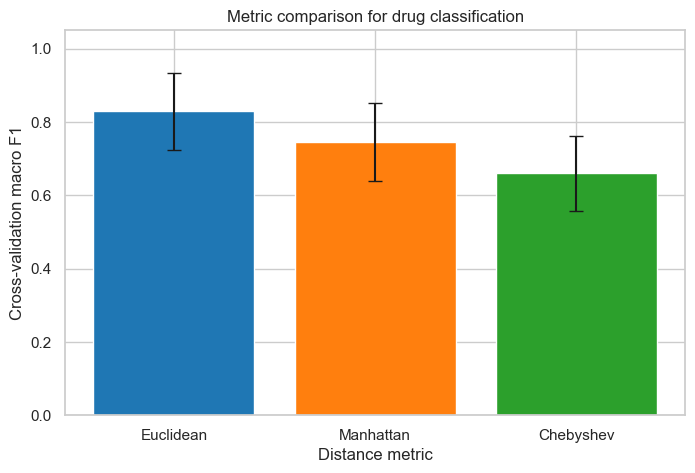

In [5]:
metric_settings = [("Euclidean", {"metric": "minkowski", "p": 2}), ("Manhattan", {"metric": "minkowski", "p": 1}), ("Chebyshev", {"metric": "chebyshev"})]
metric_rows = []
for metric_name, metric_parameters in metric_settings:
    metric_model = make_pipeline(drug_preprocessor, KNeighborsClassifier(n_neighbors=7, weights="uniform", **metric_parameters))
    metric_scores = cross_val_score(metric_model, drug_X_train, drug_y_train, cv=drug_cv, scoring=macro_f1, error_score="raise")
    metric_rows.append({"metric": metric_name, "mean_macro_f1": metric_scores.mean(), "std_macro_f1": metric_scores.std()})
metric_results = pd.DataFrame(metric_rows).sort_values("mean_macro_f1", ascending=False)
display(metric_results.round(3))

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(metric_results["metric"], metric_results["mean_macro_f1"], yerr=metric_results["std_macro_f1"], capsize=5, color=["tab:blue", "tab:orange", "tab:green"])
ax.set_ylim(0, 1.05)
ax.set_xlabel("Distance metric")
ax.set_ylabel("Cross-validation macro F1")
ax.set_title("Metric comparison for drug classification")
plt.show()

## ۶. ببینید معیارها چگونه همسایگی‌ها را شکل می‌دهند

نمای دوبعدی اسباب‌بازی، هندسه را قابل مشاهده می‌کند. پیرامون مبدأ، خطوط هم‌فاصلهٔ اقلیدسی دایره‌ای، منهتن لوزی‌شکل و چبیشف مربعی‌اند. در ابعاد بیشتر شکل‌ها به کره، cross-polytope و hypercube تبدیل می‌شوند، اما اصل همان است: معیار انتخاب‌شده تعیین می‌کند کدام مشاهده‌ها زودتر وارد همسایگی می‌شوند.

این تصویرسازی ادعا نمی‌کند دادهٔ واقعی دوبعدی‌اند. راهی برای استدلال دربارهٔ رفتار معیار است. اگر شباهت دامنه به بدترین عدم تطابق محدود است، رفتار چبیشف می‌تواند توجیه شود. اگر حرکت در مختصات هزینهٔ جمع‌شونده دارد، منهتن طبیعی است. اگر نویز اندازه‌گیری‌های مقیاس‌شده تقریباً همسانگرد و مستقل است، اقلیدسی اغلب معقول است. داده و فرایند اندازه‌گیری باید انتخاب را هدایت کنند.

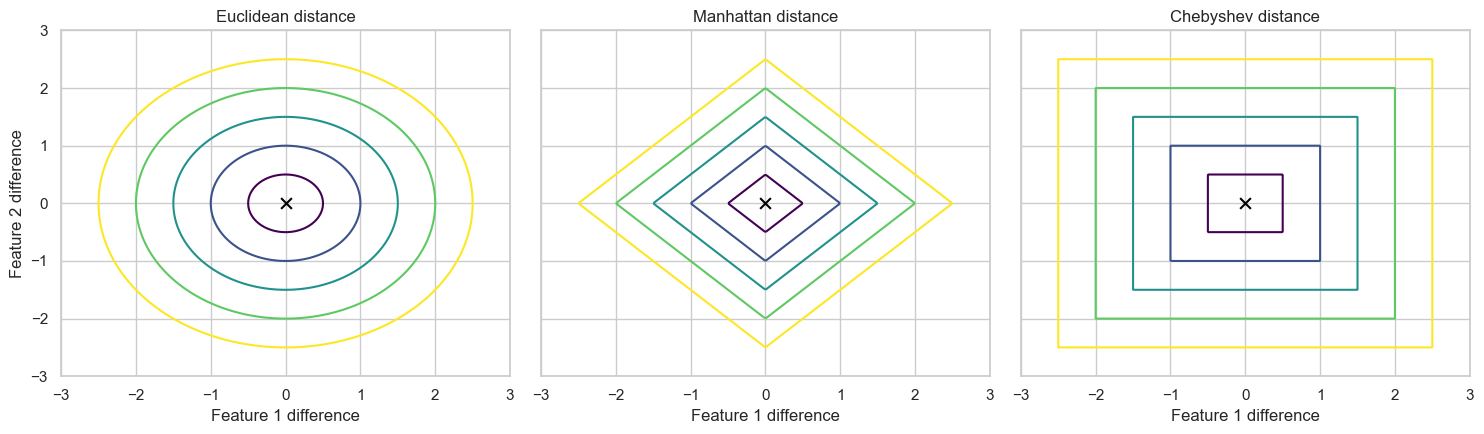

In [6]:
grid_values = np.linspace(-3, 3, 300)
grid_x, grid_y = np.meshgrid(grid_values, grid_values)
euclidean_distance = np.sqrt(grid_x**2 + grid_y**2)
manhattan_distance = np.abs(grid_x) + np.abs(grid_y)
chebyshev_distance = np.maximum(np.abs(grid_x), np.abs(grid_y))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)
for axis, distance_grid, title in zip(axes, [euclidean_distance, manhattan_distance, chebyshev_distance], ["Euclidean distance", "Manhattan distance", "Chebyshev distance"]):
    axis.contour(grid_x, grid_y, distance_grid, levels=[0.5, 1.0, 1.5, 2.0, 2.5], cmap="viridis")
    axis.scatter([0], [0], color="black", marker="x", s=60)
    axis.set_title(title)
    axis.set_xlabel("Feature 1 difference")
axes[0].set_ylabel("Feature 2 difference")
plt.tight_layout()
plt.show()

## ۷. رأی‌های یکنواخت و وزن‌دار بر حسب فاصله را مقایسه کنید

اکنون معیار را روی قوی‌ترین نامزد مقایسهٔ قبل ثابت می‌گذاریم و دو قانون رأی را می‌سنجیم. معیار ترتیب همسایه‌ها را تعیین می‌کند. رأی یکنواخت هر هفت سطر انتخاب‌شده را برابر می‌بیند. وزن‌دهی فاصله‌ای اثر سطرهای نزدیک‌تر را افزایش می‌دهد. این موضوع نزدیک مرز کلاس می‌تواند مفید باشد، اما فاصله‌های بسیار کوچک را هم اثرگذارتر می‌کند.

نتیجهٔ اعتبارسنجی باید تعیین کند آیا حساسیت محلیِ بیشتر کمک می‌کند یا نه. وسوسه‌کننده است که تصور کنیم وزن‌دهی فاصله‌ای همیشه بهتر است، زیرا نقطهٔ نزدیک‌تر مرتبط‌تر به نظر می‌رسد. این شهود هنگامی که برآورد فاصله نویزی است، نزدیک‌ترین نقطه پرت است یا ناحیهٔ محلی نمونه‌برداری تنکی دارد می‌تواند شکست بخورد. شواهد زیر مخصوص همین دادهٔ آموزش و طراحی پیش‌پردازش است.

In [7]:
best_metric_name = metric_results.iloc[0]["metric"]
best_metric_parameters = dict(metric_settings)[best_metric_name]
weight_rows = []
for weight_rule in ["uniform", "distance"]:
    weight_model = make_pipeline(drug_preprocessor, KNeighborsClassifier(n_neighbors=7, weights=weight_rule, **best_metric_parameters))
    weight_scores = cross_val_score(weight_model, drug_X_train, drug_y_train, cv=drug_cv, scoring=macro_f1, error_score="raise")
    weight_rows.append({"weights": weight_rule, "mean_macro_f1": weight_scores.mean(), "std_macro_f1": weight_scores.std()})
weight_results = pd.DataFrame(weight_rows)
display(weight_results.round(3))

,weights,mean_macro_f1,std_macro_f1
0,uniform,0.829,0.105
1,distance,0.878,0.075


## ۸. یک پیش‌بینی محلی را بازرسی کنید

KNN اغلب از مدلی که همهٔ شواهد را در پارامترهای فراوان پنهان می‌کند آسان‌تر ممیزی می‌شود. برای یک بیمار آزمون، می‌توانیم ویژگی‌ها را با پیش‌پردازشگر برازش‌شده تبدیل کنیم، همسایه‌های آموزشی انتخاب‌شده را بیابیم، سطرهای اصلی آن‌ها را ببینیم و فاصله‌هایشان را در فضای تبدیل‌شده بررسی کنیم. این توضیح محلیِ قانون مدل است، نه توضیح علّی دربارهٔ مناسب‌بودن درمان.

بازرسی مفید چند پرسش مطرح می‌کند: آیا بیماران نزدیک در ویژگی‌های خام واقعاً مشابه‌اند؟ آیا تطابق‌های دسته‌ای معقول‌اند؟ آیا یک همسایهٔ بسیار نزدیک بر رأی وزن‌دار مسلط است؟ آیا کلاس‌ها مخلوط‌اند و عدم قطعیت را نشان می‌دهند؟ این پرسش‌ها می‌توانند خطاهای نمایش را آشکار کنند که امتیاز اعتبارسنجی به‌تنهایی شاید نشان ندهد.

In [8]:
selected_weight_rule = weight_results.loc[weight_results["mean_macro_f1"].idxmax(), "weights"]
selected_drug_model = make_pipeline(drug_preprocessor, KNeighborsClassifier(n_neighbors=7, weights=selected_weight_rule, **best_metric_parameters))
selected_drug_model.fit(drug_X_train, drug_y_train)
query_patient = drug_X_test.iloc[[0]]
query_transformed = selected_drug_model.named_steps["columntransformer"].transform(query_patient)
neighbor_distances, neighbor_indices = selected_drug_model.named_steps["kneighborsclassifier"].kneighbors(query_transformed)
neighbor_rows = drug_X_train.iloc[neighbor_indices[0]].copy()
neighbor_rows["Drug"] = drug_y_train.iloc[neighbor_indices[0]].to_numpy()
neighbor_rows["distance"] = neighbor_distances[0]
prediction_probabilities = pd.DataFrame({"Drug": selected_drug_model.classes_, "probability": selected_drug_model.predict_proba(query_patient)[0]})
display(query_patient.assign(predicted_drug=selected_drug_model.predict(query_patient)))
display(neighbor_rows.sort_values("distance").round(3))
display(prediction_probabilities.sort_values("probability", ascending=False).round(3))

,Age,Sex,BP,Cholesterol,Na_to_K,predicted_drug
60,38,F,LOW,NORMAL,29.875,DrugY


,Age,Sex,BP,Cholesterol,Na_to_K,Drug,distance
93,42,F,LOW,NORMAL,29.271,DrugY,0.262
28,39,F,LOW,NORMAL,22.697,DrugY,1.026
168,51,F,LOW,NORMAL,23.003,DrugY,1.267
22,47,M,LOW,NORMAL,30.568,DrugY,1.523
19,32,F,HIGH,NORMAL,25.974,DrugY,1.564
173,41,F,LOW,NORMAL,18.739,DrugY,1.600
128,47,M,LOW,NORMAL,33.542,DrugY,1.607


,Drug,probability
0,DrugY,1.0
1,drugA,0.0
2,drugB,0.0
3,drugC,0.0
4,drugX,0.0


## ۹. ارزیابی نهایی کنارگذاشته‌شده برای طبقه‌بندی drug

معیار و قانون وزن‌دهی از شواهد foldهای آموزش انتخاب شده‌اند. اکنون pipeline حاصل را یک‌بار روی drug_X_test ارزیابی می‌کنیم. گزارش طبقه‌بندی عملکرد هر کلاس Drug را جدا می‌کند و ماتریس درهم‌ریختگی نشان می‌دهد کدام داروها با ویژگی‌های موجود اشتباه گرفته می‌شوند. امتیاز خوب نشان می‌دهد نمایش و قانون محلی برای این تقسیم کنارگذاشته‌شده کار می‌کنند؛ این نوت‌بوک را به سامانهٔ تصمیم بالینی تبدیل نمی‌کند.

در محیط واقعی درمان، برچسب‌های هدف، منشأ داده، ایمنی بیمار، انصاف زیرگروه‌ها، گم‌شدگی و هزینه‌های تصمیم به بررسی بسیار بیشتری نیاز دارند. این مثال دربارهٔ سازوکار طبقه‌بند مبتنی بر فاصله و انضباط اعتبارسنجی فرض‌های آن است.

,metric,test_value
0,accuracy,0.820
1,macro_f1,0.784


,precision,recall,f1-score,support
DrugY,0.792,0.826,0.809,23.00
drugA,1.000,0.667,0.800,6.00
drugB,1.000,0.500,0.667,4.00
drugC,0.750,0.750,0.750,4.00
drugX,0.812,1.000,0.897,13.00
accuracy,0.820,0.820,0.820,0.82
macro avg,0.871,0.749,0.784,50.00
weighted avg,0.835,0.820,0.814,50.00


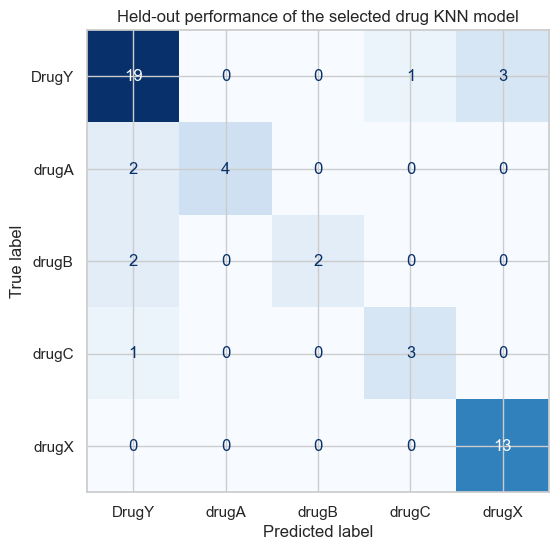

In [9]:
drug_test_predictions = selected_drug_model.predict(drug_X_test)
drug_test_accuracy = accuracy_score(drug_y_test, drug_test_predictions)
drug_test_macro_f1 = f1_score(drug_y_test, drug_test_predictions, average="macro", zero_division=0)
display(pd.DataFrame({"metric": ["accuracy", "macro_f1"], "test_value": [drug_test_accuracy, drug_test_macro_f1]}).round(3))
display(pd.DataFrame(classification_report(drug_y_test, drug_test_predictions, output_dict=True, zero_division=0)).T.round(3))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(drug_y_test, drug_test_predictions, cmap="Blues", colorbar=False, ax=ax)
ax.set_title("Held-out performance of the selected drug KNN model")
plt.show()

## ۱۰. مجموعه‌دادهٔ دوم با مقیاس‌های عددی شدید: stars.csv

دادهٔ stars شامل Temperature، luminosity یا L، radius یا R، absolute magnitude یا A_M و توصیف‌کننده‌های دسته‌ای است. سطرهای نخست نشان می‌دهند ستون‌های عددی می‌توانند دامنه‌های بسیار متفاوتی داشته باشند: luminosity و radius چند مرتبهٔ بزرگی تغییر می‌کنند، در حالی که absolute magnitude دامنهٔ باریک‌تری دارد. برای این مقایسهٔ معیار، فقط ستون‌های عددی را به‌کار می‌بریم و پیش از استانداردسازی روی L و R مثبت تبدیل لگاریتمی اعمال می‌کنیم. log transform تفاوت‌های شدید مقیاس را فشرده و ترتیب را حفظ می‌کند.

این مثال یادآور می‌شود استانداردسازی تنها انتخاب تبدیل نیست. StandardScaler ستون‌های تبدیل‌شده را از نظر واریانس قابل مقایسه می‌کند، اما متغیرهای مثبت بسیار چوله ممکن است نخست از log transform سود ببرند. تبدیل‌ها باید با توجه به اندازه‌گیری‌ها توجیه و بازرسی شوند، نه مکانیکی اضافه شوند.

In [10]:
stars_path = Path("../../../Datasets/Classification/stars.csv")
stars_df = pd.read_csv(stars_path)
stars_target = "Type"
stars_y = stars_df[stars_target]
stars_X = stars_df[["Temperature", "L", "R", "A_M"]].copy()
stars_X["log_L"] = np.log10(stars_X.pop("L"))
stars_X["log_R"] = np.log10(stars_X.pop("R"))

display(stars_df.head())
display(stars_df.dtypes.rename("dtype").to_frame())
display(stars_y.value_counts().rename("count").to_frame())
display(stars_X.describe().T.round(3))

,Temperature,L,R,A_M,Color,Spectral_Class,Type
0,3068,0.002400,0.1700,16.12,Red,M,Red Dwarf
1,3042,0.000500,0.1542,16.60,Red,M,Red Dwarf
2,2600,0.000300,0.1020,18.70,Red,M,Red Dwarf
3,2800,0.000200,0.1600,16.65,Red,M,Red Dwarf
4,1939,0.000138,0.1030,20.06,Red,M,Red Dwarf


,dtype
Temperature,int64
L,float64
R,float64
A_M,float64
Color,object
Spectral_Class,object
Type,object


,count
Type,
Red Dwarf,40
Brown Dwarf,40
White Dwarf,40
Main Sequence,40
Super Giants,40
Hyper Giants,40


,count,mean,std,min,25%,50%,75%,max
Temperature,240.0,10497.462,9552.425,1939.000,3344.250,5776.000,15055.500,40000.000
A_M,240.0,4.382,10.533,-11.920,-6.232,8.313,13.698,20.060
log_L,240.0,0.707,3.964,-4.097,-3.063,-1.161,5.297,5.929
log_R,240.0,0.306,1.712,-2.076,-0.988,-0.118,1.631,3.290


## ۱۱. مقایسهٔ معیار روی اندازه‌گیری‌های تبدیل‌شدهٔ ستاره

مقایسهٔ اعتبارسنجی فشرده را روی ویژگی‌های ستاره تکرار می‌کنیم. همهٔ ورودی‌های این مثال پس از دو log transform عددی‌اند، پس هندسهٔ آن‌ها از نمایش ترکیبی drug آسان‌تر تفسیر می‌شود. هدف چندین نوع ستاره دارد و macro F1 دوباره مانع غالب‌شدن یک کلاس پرتکرار در ارزیابی می‌شود.

ممکن است معیار انتخاب‌شده با نتیجهٔ drug فرق کند. این انتظار می‌رود. معیار یک انتخاب برند جهانی نیست؛ بیانی دربارهٔ یک فضای ویژگی مشخص است. استفادهٔ دوباره از پروتکل اعتبارسنجی ارزشمند است، زیرا حتی وقتی بهترین پیکربندی عوض می‌شود، فرض‌ها را عادلانه مقایسه می‌کند.

,metric,mean_macro_f1,std_macro_f1
1,Manhattan,0.989,0.014
0,Euclidean,0.983,0.014
2,Chebyshev,0.967,0.032


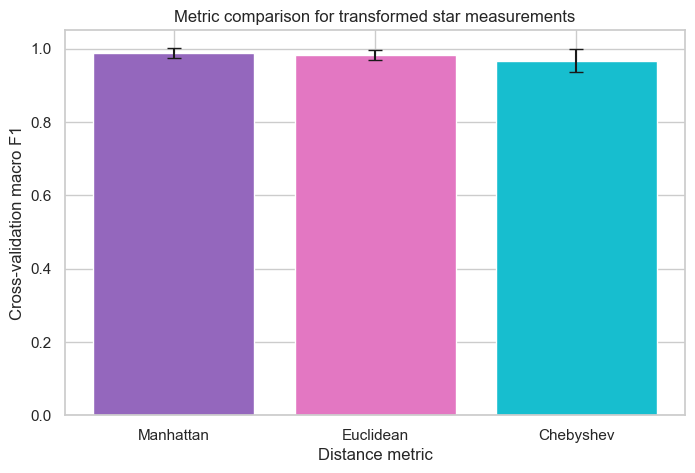

In [11]:
stars_X_train, stars_X_test, stars_y_train, stars_y_test = train_test_split(stars_X, stars_y, test_size=0.25, stratify=stars_y, random_state=RANDOM_STATE)
stars_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
stars_rows = []
for metric_name, metric_parameters in metric_settings:
    stars_model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=7, weights="distance", **metric_parameters))
    stars_scores = cross_val_score(stars_model, stars_X_train, stars_y_train, cv=stars_cv, scoring=macro_f1, error_score="raise")
    stars_rows.append({"metric": metric_name, "mean_macro_f1": stars_scores.mean(), "std_macro_f1": stars_scores.std()})
stars_results = pd.DataFrame(stars_rows).sort_values("mean_macro_f1", ascending=False)
display(stars_results.round(3))

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(stars_results["metric"], stars_results["mean_macro_f1"], yerr=stars_results["std_macro_f1"], capsize=5, color=["tab:purple", "tab:pink", "tab:cyan"])
ax.set_ylim(0, 1.05)
ax.set_xlabel("Distance metric")
ax.set_ylabel("Cross-validation macro F1")
ax.set_title("Metric comparison for transformed star measurements")
plt.show()

## ۱۲. محدودیت‌های فاصله و قانون‌های طراحی عملی

در بُعد کم، مشاهده‌های نزدیک می‌توانند واقعاً نزدیک باشند. با افزایش بُعد، فاصله‌ها تمایل به تمرکز دارند: نزدیک‌ترین و دورترین نقطه نسبت به بزرگی خود کمتر قابل تمایز می‌شوند. این نفرین بُعد یعنی افزودن ویژگی‌های ضعیف یا نامرتبط فراوان می‌تواند معنای هر همسایه را کم کند. مقیاس‌بندی اطلاعات نامرتبط را تعمیر نمی‌کند. انتخاب ویژگی، کاهش بُعد و نمایش آگاه از دامنه ممکن است از آزمودن بی‌پایان معیارها ارزشمندتر باشند.

نقطه‌های پرت چالش دیگری‌اند. اقلیدسی پیش از جمع اختلاف‌ها را مربع می‌کند، پس اختلاف بزرگ می‌تواند اثر زیادی داشته باشد. منهتن اغلب در برابر یک اختلاف مختصات بزرگ تحمل بیشتری دارد، اما از اندازه‌گیری بد مصون نیست. متغیرهای one-hot دسته‌ای نیز اگر ستون‌های پُرتعداد داشته باشند می‌توانند غالب شوند. بررسی کنید آیا دسته‌ها باید گروه شوند، آیا دسته‌های نادر مدیریت ویژه می‌خواهند و آیا خانوادهٔ مدل دیگری با داده سازگارتر است.

جریان کاری درست فاصله چنین است: ستون‌های خام را ببینید، شناسه و نشت را حذف کنید، تبدیل‌های سازگار با معنای اندازه‌گیری انتخاب کنید، تبدیل‌ها را در pipeline نگه دارید، مجموعهٔ کوچک و موجهی از معیارها و وزن‌ها را با اعتبارسنجی متقابل مقایسه کنید، همسایه‌های محلی را ببینید و یک‌بار روی دادهٔ کنارگذاشته‌شده ارزیابی کنید.

## ۱۳. تمرین‌ها و جمع‌بندی

1. در pipeline drug، هر بار یک ستون دسته‌ای را حذف و جدول معیارها را مقایسه کنید. کدام دسته در این نمایش بیشترین کمک را دارد؟
2. تعداد همسایه‌ها را از 7 به چند مقدار فرد تغییر دهید و بیازمایید آیا معیار ترجیحی پایدار می‌ماند.
3. pipeline دارای StandardScaler و بدون آن را برای ستون‌های عددی drug مقایسه کنید. توضیح دهید هر تفاوت امتیاز چرا اثر هندسی است.
4. روی stars، L و R خام را با L و R لگاریتمی مقایسه کنید. کدام نمایش امتیازهای اعتبارسنجی پایدارتر می‌دهد؟
5. یک پیش‌بینی آزمون drug با برچسب‌های همسایهٔ مخلوط پیدا کنید. توضیح دهید وزن‌دهی یکنواخت و فاصله‌ای با این شواهد محلی چگونه رفتار متفاوتی دارند.

### جمع‌بندی

KNN یک معنای درونی و یگانه از نزدیک ندارد. معیار فاصله هندسهٔ همسایگی را می‌سازد و قانون وزن‌دهی کنترل می‌کند شواهد درون همسایگی چگونه تجمیع شوند. اقلیدسی، منهتن و چبیشف بر الگوهای متفاوت مختصات تأکید می‌کنند. وزن‌دهی یکنواخت و فاصله‌ای باورهای متفاوتی دربارهٔ اثر محلی بیان می‌کنند. برای مقیاس‌بندی ویژگی‌های عددی و کدگذاری ایمن دسته‌ها از pipeline استفاده کردیم، انتخاب‌ها را با اعتبارسنجی متقابل مقایسه کردیم، همسایه‌های واقعی را دیدیم و مدل‌های انتخاب‌شده را روی دادهٔ دیده‌نشده ارزیابی کردیم. معیار و قانون وزن درست آن‌هایی هستند که با نمایش خوب طراحی‌شده هماهنگ‌اند و در اعتبارسنجی صادقانه پایدار می‌مانند.